In [54]:
import numpy as np
import pandas as pd
import cooler

import matplotlib.pyplot as plt
from tqdm import tqdm, trange

from itertools import combinations
import pybedtools

plt.style.use('default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

In [2]:
#### HiPore-C GM12878 1Mb Unobserved_MCI_O3: SGMCI vs MATCHA

Unobserved_MCI_O3 = np.load('/data/xujs/Project/HiC2PoreC/code/SGMCI/Analysis_Results/2024-05-23_Predict_New_MCI/HiPore-C_GM12878_1Mb.Unobserved_MCI_O3.npy')
SGMCI_O3_pred = np.load('/data/xujs/Project/HiC2PoreC/code/SGMCI/Analysis_Results/2024-05-23_Predict_New_MCI/HiPore-C_GM12878_1Mb.Unobserved_MCI_O3_pred_score.npy')
matcha_O3_pred = np.load('/data/xujs/Project/HiC2PoreC/code/SGMCI/Analysis_Results/2024-05-31_Model_comparison/MATCHA/1Mb_Code/HiPore-C_GM12878_1Mb.MATCHA_Unobserved_MCI_O3_pred_score.npy')

In [3]:
SGMCI_bool = (SGMCI_O3_pred > 0.5).reshape(-1)
matcha_bool = (matcha_O3_pred > 0.5).reshape(-1)

In [4]:
SGMCI_num = SGMCI_O3_pred[SGMCI_bool].shape[0]
matcha_num = matcha_O3_pred[matcha_bool].shape[0]
ov_num = Unobserved_MCI_O3[(SGMCI_bool & matcha_bool)].shape[0]

In [5]:
SGMCI_num, matcha_num, ov_num

(373895, 123062, 105966)

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


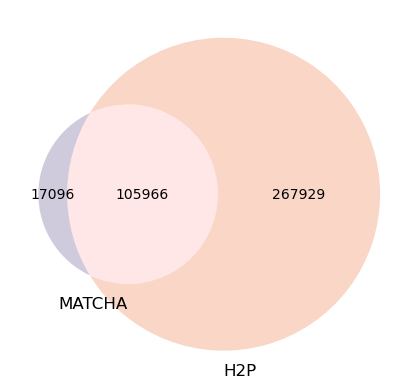

In [6]:
from matplotlib_venn import venn2


plt.figure()
venn2((matcha_num - ov_num, SGMCI_num - ov_num, ov_num),
       set_labels = ('MATCHA', 'SGMCI'),
       set_colors = ('#897ea8', '#f09a6e'))
plt.savefig('./MATCHA_SGMCI_O3.overlap_vennplot.pdf')
plt.show()

In [139]:
17096 / (105966 + 17096), 105966 / (105966 + 17096)

(0.13892184427361817, 0.8610781557263818)

In [140]:
267929 / (105966 + 267929), 105966 / (105966 + 267929)

(0.7165888819053478, 0.28341111809465225)